/tmp/ipython-input-3977767591.py:107: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp(beta * (EJ - muJ)) + 1.0)


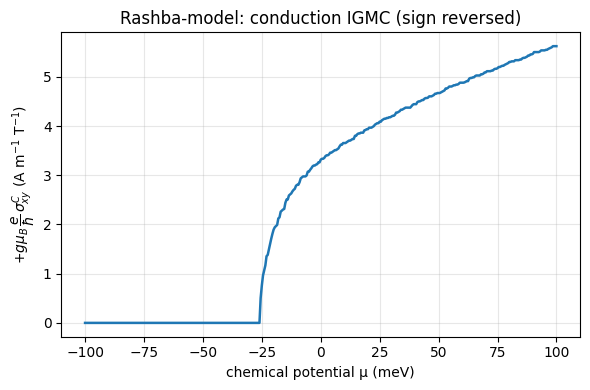

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh

# ---------------- physical constants (SI) ----------------
e_charge = 1.602176634e-19     # C
hbar     = 1.054571817e-34     # J*s
muB_SI   = 9.2740100783e-24    # J/T
m_e      = 9.1093837015e-31    # kg
pi = np.pi

# ---------------- model parameters (paper-like) ----------
lambdaR_eVA = 0.6             # eV * Angstrom
lambdaR_SI = lambdaR_eVA * e_charge * 1e-10  # convert to J*m
m_eff = 1.1 * m_e             # effective mass in kg
g = 2.0                       # g-factor
gamma_eV = 0.0
gamma_SI = gamma_eV * e_charge
a_ang = 1.0
a = a_ang * 1e-10             # in meters

# Pauli matrices
sx = np.array([[0,1],[1,0]], dtype=complex)
sy = np.array([[0,-1j],[1j,0]], dtype=complex)
sz = np.array([[1,0],[0,-1]], dtype=complex)
sigma0 = np.eye(2, dtype=complex)

# ---- Hamiltonian & derivatives (SI) ----
def H_k_SI(kx, ky):
    kinetic = (hbar**2) * (kx**2 + ky**2) / (2.0 * m_eff)
    rashba  = lambdaR_SI * (ky * sx - kx * sy)
    tilt    = gamma_SI * (np.cos(kx * a) - np.cos(pi/2.0)) * sigma0
    return kinetic * sigma0 + rashba + tilt

def dHdkx_SI(kx, ky):
    dkin = (hbar**2 / m_eff) * kx * sigma0
    drash = - lambdaR_SI * sy
    dtilt = - gamma_SI * a * np.sin(kx * a) * sigma0
    return dkin + drash + dtilt

def dHdky_SI(kx, ky):
    dkin = (hbar**2 / m_eff) * ky * sigma0
    drash = lambdaR_SI * sx
    return dkin + drash

# ---- Zeeman Z (Z_xy^{-+}) ----
def zeeman_Z_xy_minusplus_SI(kx, ky):
    H = H_k_SI(kx, ky)
    evals, evecs = eigh(H)
    eps_m, eps_p = evals[0], evals[1]
    u_m = evecs[:,0]
    u_p = evecs[:,1]
    delta = eps_p - eps_m
    if abs(delta) < 1e-20:
        delta = 1e-20

    dHx = dHdkx_SI(kx, ky)
    dHy = dHdky_SI(kx, ky)

    r_mp_x = 1j * np.vdot(u_m, dHx @ u_p) / delta
    r_mp_y = 1j * np.vdot(u_m, dHy @ u_p) / delta
    r_pm_x = np.conjugate(r_mp_x)
    r_pm_y = np.conjugate(r_mp_y)

    s_x_pm = np.vdot(u_p, sx @ u_m)
    s_y_pm = np.vdot(u_p, sy @ u_m)
    s_x_mp = np.vdot(u_m, sx @ u_p)
    s_y_mp = np.vdot(u_m, sy @ u_p)

    Zxy_mp = 1j * ( r_mp_x * s_y_pm - r_pm_x * s_y_mp )
    return np.real(Zxy_mp), eps_m, eps_p

# ---- k-grid (2D) and precompute ----
kmax = pi / a
Nkx = 600
Nky = 600
kx_vals = np.linspace(-kmax, kmax, Nkx)
ky_vals = np.linspace(-kmax, kmax, Nky)
dkx = kx_vals[1] - kx_vals[0]
dky = ky_vals[1] - ky_vals[0]
area_factor = (dkx * dky) / (2.0 * pi)**2

K_pts = Nkx * Nky
Z_vals = np.zeros(K_pts)
E_minus = np.zeros(K_pts)
E_plus  = np.zeros(K_pts)

idx = 0
for kx in kx_vals:
    for ky in ky_vals:
        Zxy, em, ep = zeeman_Z_xy_minusplus_SI(kx, ky)
        Z_vals[idx] = Zxy
        E_minus[idx] = em
        E_plus[idx]  = ep
        idx += 1

# ---- mu sweep (x-axis in meV) ----
mu_eV_vals = np.linspace(-0.1, 0.1, 401)    # eV
mu_SI_vals  = mu_eV_vals * e_charge             # Joules
T = 1e-3   # K small smoothing
kB_J = 1.380649e-23

def fermi_SI(EJ, muJ, T):
    if T <= 0.0:
        return (EJ < muJ).astype(float)
    beta = 1.0 / (kB_J * T)
    return 1.0 / (np.exp(beta * (EJ - muJ)) + 1.0)

sigmaC_vs_mu = np.zeros_like(mu_SI_vals)
for imu, muJ in enumerate(mu_SI_vals):
    f_minus = fermi_SI(E_minus, muJ, T)
    # using f_minus contribution (as before)
    integrand = (f_minus) * Z_vals
    sigmaC_vs_mu[imu] = np.sum(integrand) * area_factor

# ---- REVERSED sign: remove leading negative -> flip vertically ----
prefactor = + g * muB_SI * (e_charge / hbar)   # NOTE: positive sign -> reverses orientation
plot_y = prefactor * sigmaC_vs_mu              # units: A m^-1 T^-1

# ---- Plot (x in meV) ----
plt.figure(figsize=(6,4))
plt.plot(mu_eV_vals*1000.0, plot_y, lw=1.8)
plt.xlabel('chemical potential μ (meV)')
plt.ylabel(r'$+g\mu_B \,\dfrac{e}{\hbar}\,\sigma^C_{xy}$ (A m$^{-1}$ T$^{-1}$)')
plt.title('Rashba-model: conduction IGMC (sign reversed)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
